# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


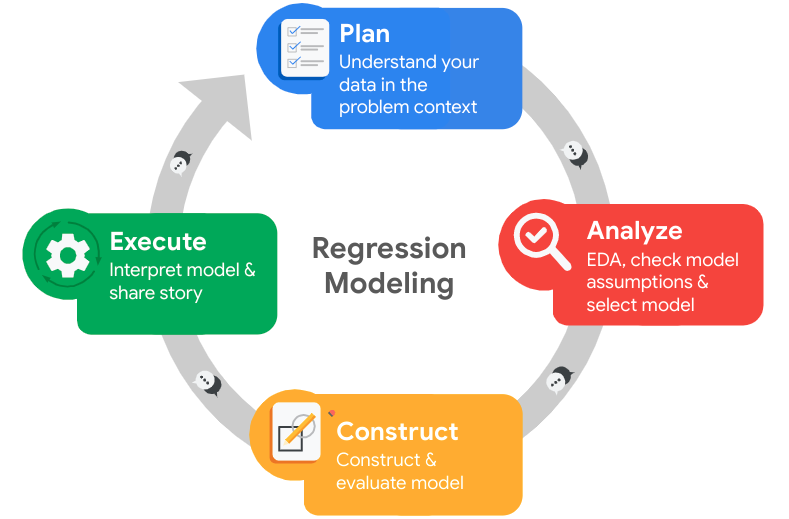

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




1. Who are your stakeholders for this project?

Salifort Motors' senior leadership team, who commissioned this analysis and will decide on any retention policy changes, and the HR department, who conducted the original survey and would be responsible for implementing any recommended interventions (e.g., retention check-ins, workload policy changes).


2. What are you trying to solve or accomplish?

Identify what's driving employee turnover at Salifort Motors and build a predictive model that flags employees likely to leave, so HR can intervene proactively rather than losing valuable employees with no warning. The end goal is actionable retention recommendations, not just a predictive model in isolation.


3. What are your initial observations when you explore the data?

The dataset contains 14,999 rows and 10 columns of self-reported employee survey data, with no missing values in any column. It includes a mix of continuous variables (satisfaction level, last evaluation score, average monthly hours), discrete counts (number of projects, tenure in years), and categorical fields (department, salary tier). The target variable, left, is binary. At this early stage, before any cleaning, roughly 24% of records show left = 1 — though this number should be treated cautiously until duplicate and data-quality checks are complete.

4. What resources do you find yourself using as you complete this stage?

Kaggle: HR Analytics and Job Prediction dataset — data source and column documentation
pandas documentation — for initial data loading and inspection methods
scikit-learn documentation — anticipating model-building needs later in the project

5. Do you have any ethical considerations in this stage?

A model that predicts which employees are likely to leave carries real risk of misuse — it could be applied punitively (e.g., deprioritizing flagged employees for opportunities or raises) rather than supportively. It's worth stating explicitly, even at this planning stage, that the intended use is proactive retention support, not employee surveillance or a justification for adverse treatment. There's also a data-quality consideration worth flagging early: this is self-reported survey data, which carries inherent subjectivity that should be kept in mind when interpreting results later.


## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
### YOUR CODE HERE ### 
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns


### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df0.head(10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
### YOUR CODE HERE ###
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns as needed
df0 = df0.rename(columns={
    'average_montly_hours': 'average_monthly_hours',
    'Work_accident': 'work_accident',
    'Department': 'department'
})


# Display all column names after the update
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
### YOUR CODE HERE ###
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated().sum()

3008

In [9]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[df0.duplicated(keep=False)].sort_values(by=['satisfaction_level', 'last_evaluation']).head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
30,0.09,0.62,6,294,4,0,1,0,accounting,low
12030,0.09,0.62,6,294,4,0,1,0,accounting,low
14241,0.09,0.62,6,294,4,0,1,0,accounting,low
71,0.09,0.77,5,275,4,0,1,0,product_mng,medium
652,0.09,0.77,6,290,4,0,1,0,technical,medium


In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df1 = df0.drop_duplicates(keep='first')

# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df1.head(10)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


In [11]:
df1.shape

(11991, 10)

### Check outliers

Check for outliers in the data.

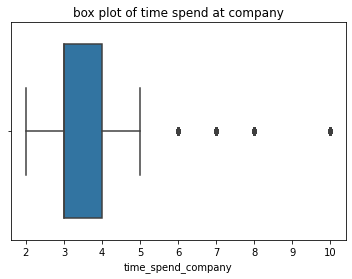

In [12]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
### YOUR CODE HERE ###
sns.boxplot(data=df1, x='time_spend_company')

plt.title('box plot of time spend at company')
plt.show()


In [13]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###
q1 = df1['time_spend_company'].quantile(0.25) 
q3 = df1['time_spend_company'].quantile(0.75) 

iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr) 
upper_bound = q3 + (1.5 * iqr) 

outliers = df1[(df1['time_spend_company'] < lower_bound) | (df1['time_spend_company'] > upper_bound)]
print('Number of rows with outliers:', len(outliers))


Number of rows with outliers: 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




1. What did you observe about the relationships between variables?

Several relationships turned out to be non-linear, which shaped the eventual model choice. number_project showed a U-shaped relationship with left: attrition was highest at 2 projects (54.2%) and 7 projects (100%), but lowest at 3–4 projects (1.1%–6.4%) — both under- and over-allocation predict leaving, not a simple linear "more work → more turnover" pattern. time_spend_company showed a similar non-monotonic shape: attrition rose steadily to a peak of 45.4% at exactly 5 years, then dropped to 0% for every employee at 7+ years' tenure. Cross-referencing average_monthly_hours against satisfaction_level for employees who left revealed three distinct density clusters rather than one relationship: an underworked/moderately-dissatisfied group (~90–150 hrs, 0.2–0.6 satisfaction), an overworked/miserable group (~230–320 hrs, 0–0.2 satisfaction), and a surprising overworked-but-satisfied group (~190–270 hrs, 0.6–1.0 satisfaction). By contrast, salary showed a clean, expected monotonic relationship — attrition fell steadily from 20.5% (low) to 4.8% (high) — and department showed almost no relationship, staying within a narrow 12–19% band across all ten departments.

2. What do you observe about the distributions in the data?

satisfaction_level among employees who left is multimodal — three separate peaks around 0.10, 0.40, and 0.80, with almost no one in between — rather than a single, smoothly distributed range. That means the average satisfaction score for leavers (0.44) is nearly meaningless on its own, since it falls in a valley where almost no actual employee sits. By contrast, employees who stayed show a single-peaked distribution centered higher (mean 0.67). time_spend_company is right-skewed, concentrated at 2–4 years with a long tail out to 10 years. average_monthly_hours and number_project are both discrete/bounded but don't show any single central tendency once split by left — their distributions shift shape entirely depending on which subgroup of leavers you're looking at.

3. What transformations did you make with your data? Why did you choose to make those decisions?

Renamed columns for clarity and consistency (fixed the average_montly_hours typo, standardized Work_accident→work_accident and Department→department to lowercase snake_case) so column references would be predictable and typo-free throughout the rest of the project. Identified and removed 3,008 exact-duplicate rows (~20% of the dataset) — justified because duplicates matched on every column including two continuous variables (satisfaction_level, last_evaluation), which is not plausible as coincidence across independent employees. This shifted the measured attrition rate from 23.8% to 16.6%, revealing duplicates were concentrated among leavers rather than evenly spread — an important finding in its own right. Ran IQR-based outlier detection on time_spend_company, flagging 824 rows (6+ years) — but chose not to drop them, since later EDA showed this "outlier" group is actually the most loyal segment (0% attrition at 7+ years), meaning dropping them would have discarded valuable signal rather than noise.

4. What are some purposes of EDA before constructing a predictive model?

EDA surfaces the actual shape of relationships in the data — U-shaped, multimodal, monotonic — which determines which model family is appropriate. Without it, I might have defaulted to logistic regression and gotten a misleading fit, since its core linearity assumption is directly violated by number_project and time_spend_company. EDA also catches data quality issues (the 20% duplicate rate) that would otherwise silently bias any model trained on the raw data, and it reveals that a single population (e.g., "employees who left") can actually be several distinct subpopulations with different underlying causes — informing not just model choice but how results should eventually be interpreted and acted on.

5. What resources do you find yourself using as you complete this stage?

seaborn documentation — for boxplot, scatterplot, histplot, and countplot usage
matplotlib documentation — figure/axis configuration
pandas documentation: .quantile(), .crosstab(), .groupby() — for the IQR outlier calculation and cross-tabulated attrition rates

6. Do you have any ethical considerations in this stage?

satisfaction_level and last_evaluation are self-reported, which carries inherent subjectivity — two employees in objectively similar situations might report very differently based on personality or context, and that noise could get mistaken for signal. The high salary group is also much smaller (990 employees) than low or medium (5,740 and 5,261), meaning any conclusions about high earners rest on comparatively thin data and should be stated with appropriate caution rather than the same confidence as the larger groups.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [14]:
# Get numbers of people who left vs. stayed
df1['left'].value_counts()

# Get percentages of people who left vs. stayed
df1['left'].value_counts(normalize=True)


0    0.833959
1    0.166041
Name: left, dtype: float64

### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

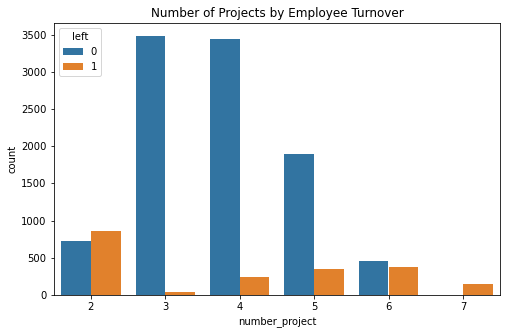

In [15]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(8,5))
sns.countplot(data=df1, x='number_project', hue='left')
plt.title('Number of Projects by Employee Turnover')
plt.show()

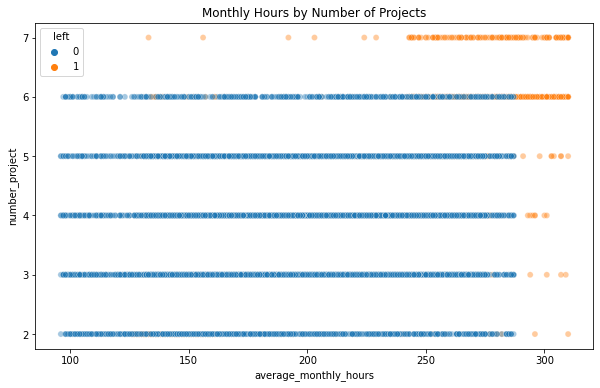

In [16]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(10,6))
sns.scatterplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', alpha=0.4)
plt.title('Monthly Hours by Number of Projects')
plt.show()

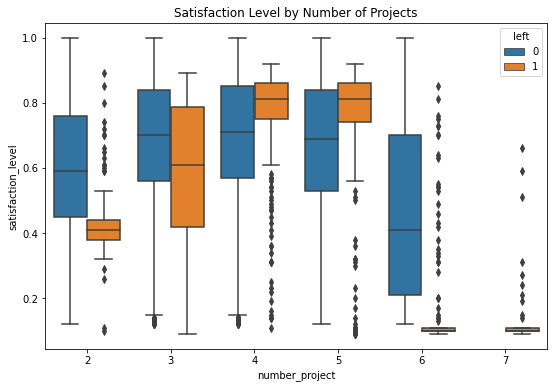

In [17]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(9,6))
sns.boxplot(data=df1, x='number_project', y='satisfaction_level', hue='left')
plt.title('Satisfaction Level by Number of Projects')
plt.show()

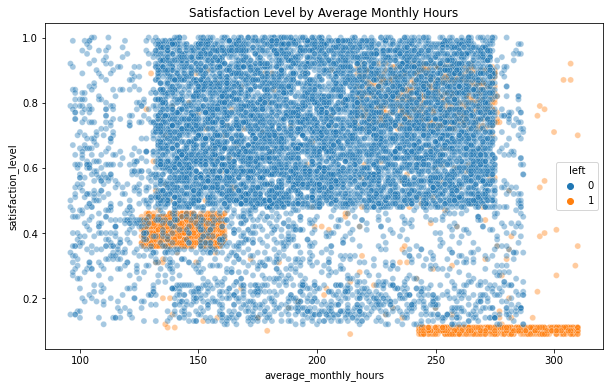

In [18]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(10,6))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.title('Satisfaction Level by Average Monthly Hours')
plt.show()

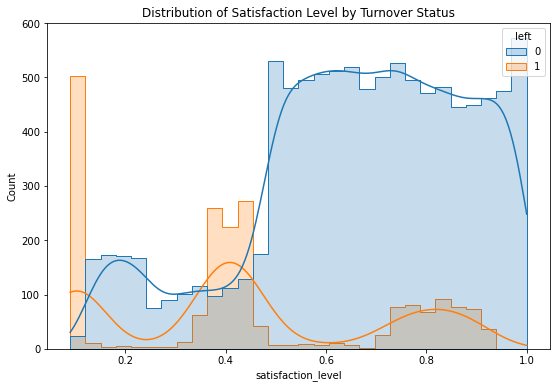

In [19]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(9,6))
sns.histplot(data=df1, x='satisfaction_level', hue='left', bins=30, kde=True, element='step')
plt.title('Distribution of Satisfaction Level by Turnover Status')
plt.show()

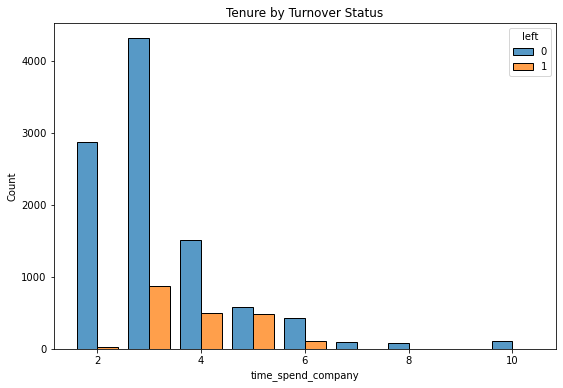

In [20]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(9,6))
sns.histplot(data=df1, x='time_spend_company', hue='left', discrete=True, multiple='dodge', shrink=0.8)
plt.title('Tenure by Turnover Status')
plt.show()

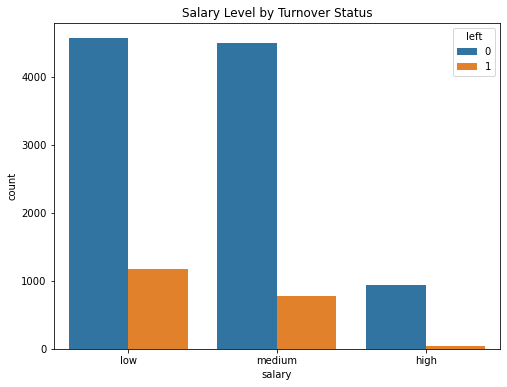

In [22]:
# Create a plot as needed
### YOUR CODE HERE ###
order = ['low', 'medium', 'high']
plt.figure(figsize=(8,6))
sns.countplot(data=df1, x='salary', hue='left', order=order)
plt.title('Salary Level by Turnover Status')
plt.show()

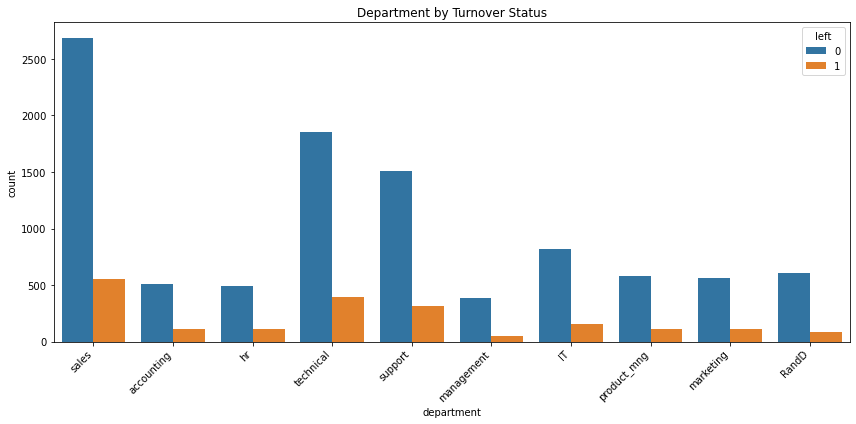

In [23]:
# Create a plot as needed
### YOUR CODE HERE ###
plt.figure(figsize=(12,6))
sns.countplot(data=df1, x='department', hue='left')
plt.title('Department by Turnover Status')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Insights

Employees who left fall into three distinct groups, not one: (1) underworked/moderately dissatisfied (2 projects, low hours), (2) overworked/burned out (6–7 projects, very high hours, lowest satisfaction in the dataset), and (3) overworked but still satisfied — likely leaving for reasons outside this dataset (external offers, promotions).

number_project and average_monthly_hours show a U-shaped, not linear, relationship with attrition — both too few and too many projects predict leaving.

satisfaction_level is multimodal among leavers (peaks near 0.1, 0.4, and 0.8) rather than uniformly low — a single average satisfaction score would misrepresent this group.

Attrition risk peaks at 5 years' tenure (45%) then drops to 0% for 7+ years — the tenure outliers flagged earlier are actually the most loyal segment, not a risk group.

salary shows a clean, expected relationship: attrition falls from 20.5% (low) to 4.8% (high).

department is a weak predictor — attrition stays within a narrow 12–19% band across all departments.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



1. Do you notice anything odd?

Several things stood out. First, 20% of the raw dataset (3,008 rows) turned out to be exact duplicates — an unusually high rate, and not evenly distributed between leavers and stayers, which shifted the measured attrition rate from 23.8% to 16.6% once removed. Second, the tenure group initially flagged as statistical outliers by the IQR method (6+ years, 824 rows) turned out to be the most loyal employees in the dataset, not a risk group — the opposite of what "outlier" usually implies in a business sense. Third, during model evaluation, XGBoost's results shifted slightly between two runs on different machines with the same random_state (confusion matrix and feature importance rankings both varied marginally) — a reminder that gradient boosting's parallelized tree construction isn't perfectly reproducible across environments, even with a fixed seed, due to floating-point non-associativity.

2. Which independent variables did you choose for the model and why?

All available features were used except left (the target) and satisfaction_level, which was deliberately excluded. The reasoning: satisfaction_level is self-reported at the same time as the outcome, and there's a real risk it reflects an employee's already-made decision to leave rather than functioning as an independent driver of that decision — including it risked the model leaning on a variable entangled with the outcome rather than genuinely predictive of it, and it also would have crowded out the more actionable, structural features (workload, tenure) that HR can actually intervene on. department (nominal, no inherent order) was one-hot encoded; salary (ordinal — low/medium/high) was integer-mapped instead, to preserve its rank rather than treating it as unordered categories.

3. Are each of the assumptions met?

This is where the model choice mattered directly: logistic regression carries real statistical assumptions — linearity between predictors and the log-odds of the outcome, independence of errors, no severe multicollinearity — and EDA had already shown two of the strongest predictors (number_project, time_spend_company) violate the linearity assumption outright (both are U-shaped/non-monotonic). That's a primary reason tree-based models were chosen instead: decision trees, random forests, and XGBoost don't require those assumptions, since they split on thresholds rather than fitting a linear relationship. The trade-off is losing the clean, single-coefficient interpretability logistic regression would have offered — but given the non-linear patterns found, that interpretability would have been somewhat misleading anyway.

4. How well does your model fit the data?

All three tree-based models fit strongly: Decision Tree (recall 0.928, F1 0.893, AUC 0.966), Random Forest (recall 0.898, F1 0.919, AUC 0.970), and the selected final model, XGBoost (recall 0.908, precision 0.936, F1 0.922, AUC 0.972, accuracy 0.974). XGBoost correctly identified 452 of 498 actual leavers in the test set, with only 31 false positives among the 2,500 employees who actually stayed.

5. Can you improve it? Is there anything you would change about the model?

Yes — a few directions worth pursuing: applying SMOTE or another resampling technique to address the class imbalance (16.6% positive class) more directly rather than relying solely on GridSearchCV's recall-scoring to compensate; widening the hyperparameter grid search space, since the current grids were deliberately modest; and adding features not present in this dataset — exit-interview reasons, manager-relationship quality, or compensation trajectory over time — which would likely help explain the "satisfied but left" cluster that current features can't fully account for. Given the run-to-run variance observed in XGBoost, it would also be worth averaging results across multiple random seeds before reporting final metrics, rather than relying on a single train/test split.

6. What resources do you find yourself using as you complete this stage?

scikit-learn: DecisionTreeClassifier, RandomForestClassifier
scikit-learn: GridSearchCV
XGBoost documentation
pandas: get_dummies — for one-hot encoding department

7. Do you have any ethical considerations in this stage?

Two worth naming explicitly. First, proxy-discrimination risk: department and salary aren't protected characteristics themselves, but it's worth staying alert to whether they (or their interaction with other features) could indirectly correlate with protected attributes not present in this dataset. Second, and more central to this project: a model that flags "at-risk" employees is only ethically sound if it's used to trigger supportive action — proactive retention conversations — rather than being repurposed to justify reduced opportunities, deprioritized raises, or other adverse treatment of the individuals it flags. That intended-use boundary is worth stating explicitly to stakeholders when the model is handed off, not left implicit.

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

This is a binary classification task — predicting whether an employee will leave the company (left = 1) or stay (left = 0), based on their attributes. The target variable is categorical with exactly two outcomes, not a continuous value, which rules out regression-for-a-number approaches and points toward a classifier.

### Identify the types of models most appropriate for this task.

Given a binary classification target, the two broad options are a statistical approach (logistic regression) or tree-based machine learning models (decision tree, random forest, XGBoost). This project uses the tree-based path — decision tree, random forest, and XGBoost, in that order — chosen over logistic regression because EDA revealed non-linear, non-monotonic relationships between key predictors and the outcome (number_project and time_spend_company both show U-shaped patterns rather than linear ones), which violates logistic regression's core assumption of linearity between predictors and the log-odds of the outcome. Tree-based models split on thresholds rather than fitting a linear relationship, so they handle this kind of pattern natively without requiring manual feature engineering to approximate it.

### Modeling

Add as many cells as you need to conduct the modeling process.

In [24]:
### YOUR CODE HERE ###
# 1. Define target and features
y = df1['left']
X = df1.drop(columns=['left', 'satisfaction_level'])

# 2. Encode categoricals
# salary: ordinal — map to integers preserving order
X['salary'] = X['salary'].map({'low': 0, 'medium': 1, 'high': 2})

# department: nominal — one-hot encode
X = pd.get_dummies(X, columns=['department'], drop_first=False)

# 3. Train/test split, stratified on y to preserve class balance
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)


In [25]:
# decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

dt_params = {
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [2, 4]
}
dt = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt, dt_params, cv=5, scoring='recall', n_jobs=-1)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_

In [26]:
# random forest
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [100, 300],
    'max_depth': [6, 10, None],
    'min_samples_leaf': [1, 2],
}
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='recall', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

In [27]:
# XGBoost
import xgboost as xgb

xgb_params = {
    'n_estimators': [100, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}
xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=5, scoring='recall', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_

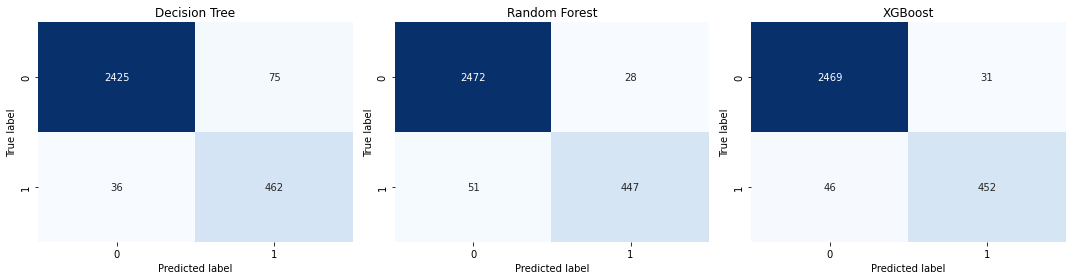

           model  accuracy  precision    recall        f1       auc
0  Decision Tree  0.962975   0.860335  0.927711  0.892754  0.966154
1  Random Forest  0.973649   0.941053  0.897590  0.918808  0.970322
2        XGBoost  0.974316   0.935818  0.907631  0.921509  0.971875


In [29]:
# --- Evaluate all three models ---
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, model) in zip(axes, [('Decision Tree', dt_best), ('Random Forest', rf_best), ('XGBoost', xgb_best)]):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
plt.tight_layout()
plt.show()

results = []
for name, model in [('Decision Tree', dt_best), ('Random Forest', rf_best), ('XGBoost', xgb_best)]:
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'auc': roc_auc_score(y_test, proba)
    })
results_df = pd.DataFrame(results)
print(results_df)

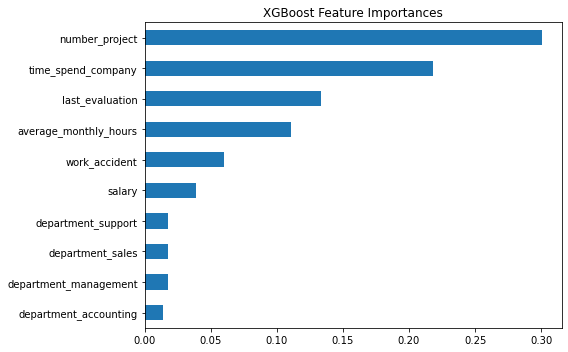

In [30]:
# --- Feature importance for chosen model (XGBoost) ---
importances = pd.Series(xgb_best.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
importances.sort_values().plot(kind='barh')
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.show()

# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?

Attrition isn't one phenomenon — at least three distinct leaver profiles exist (underworked/disengaged at 2 projects, overworked/burned out at 6–7 projects, and a third group that's overworked but still satisfied and likely leaving for external reasons). number_project and time_spend_company are the two dominant predictors; attrition risk is non-linear on both, peaking at 5 years' tenure (45%) then dropping to 0% at 7+ years.

- What business recommendations do you propose based on the models built?

Cap project load around 3–4 per employee where feasible, since both under- and over-allocation (2 or 6–7 projects) correlate strongly with leaving. Build a targeted retention check-in specifically around the 5-year tenure mark, the single highest-risk point in the data.

- What potential recommendations would you make to your manager/company?

Treat the "satisfied but left" segment as a separate retention problem — since they show no dissatisfaction signal, standard engagement or satisfaction initiatives won't retain them; compensation and career-growth pathways are more likely levers. Use the model's output as a proactive flag for supportive HR outreach, not as a performance or disciplinary signal.

- Do you think your model could be improved? Why or why not? How?

Yes — the class imbalance (16.6% left) could be addressed with resampling techniques like SMOTE to see if recall improves further; additional features not in this dataset (manager relationship quality, compensation trajectory, exit interview reasons) would likely sharpen predictions, especially for the "satisfied but left" cluster that current features can't fully explain.

- Given what you know about the data and the models you were using, what other questions could you address for the team?

What specifically motivates the "satisfied but left" group to leave despite high satisfaction (would require exit-interview data)? Does attrition risk by department shift once workload and tenure are controlled for, given department's weak standalone signal? Would a lower project-count ceiling measurably reduce burnout-driven attrition if tested going forward?

- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)

scikit-learn metrics documentation, XGBoost documentation.
https://scikit-learn.org/stable/modules/model_evaluation.html
https://xgboost.readthedocs.io/

- Do you have any ethical considerations in this stage?

The model should trigger supportive HR outreach, not grounds for reduced opportunities, negative performance reviews, or targeted treatment of flagged employees — a real risk if leadership misapplies a retention-prediction tool as a surveillance or punitive mechanism instead.



Double-click to enter your responses here.

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

Three tree-based models were built and tuned via GridSearchCV (5-fold CV, optimized for recall): Decision Tree, Random Forest, and XGBoost. All three performed strongly (AUC 0.966–0.972). XGBoost was selected as the final model — while Decision Tree had marginally higher raw recall (0.928 vs. 0.908), its cross-validation recall was also nearly twice as variable (±1.35% vs. XGBoost's ±1.07%), making XGBoost's performance more trustworthy for deployment on new data. XGBoost achieved recall 0.908, precision 0.936, F1 0.922, and AUC 0.972 — the best F1 and AUC of the three models — correctly identifying the large majority of employees who left (452 of 498) while keeping false alarms low (31 false positives out of 2,500 test cases). number_project and time_spend_company were the two dominant predictors, consistent with EDA findings.

### Conclusion, Recommendations, Next Steps

The final XGBoost model reliably predicts employee attrition (AUC 0.972, recall 0.908, F1 0.922) using workload and tenure signals as the primary drivers. Recommendations: (1) reassess project-load policy — both under- and over-allocation correlate strongly with leaving; (2) build a targeted retention check-in around the 5-year tenure mark; (3) treat "satisfied but left" employees as a distinct group requiring compensation/growth-path solutions rather than engagement fixes. Next steps: deploy the model to flag at-risk current employees for proactive HR outreach; gather additional data (exit interviews, compensation history) to better explain the "satisfied but left" segment; monitor model performance over time and retrain periodically as workforce patterns shift.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.